# Pertemuan 5 - Visualisasi Data

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Dashboard visualisasi statis menggunakan dataset Tips.


## 1. Load Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
np.random.seed(42)

# Dataset tips sintetis dengan struktur seperti dataset tips Seaborn
n = 244
df = pd.DataFrame({
    "total_bill": np.random.gamma(shape=4.0, scale=5.0, size=n).clip(5, 55),
    "sex": np.random.choice(["Male", "Female"], n, p=[0.65, 0.35]),
    "smoker": np.random.choice(["Yes", "No"], n, p=[0.38, 0.62]),
    "day": np.random.choice(["Thur", "Fri", "Sat", "Sun"], n, p=[0.25, 0.08, 0.35, 0.32]),
    "time": np.random.choice(["Lunch", "Dinner"], n, p=[0.32, 0.68]),
    "size": np.random.choice([1,2,3,4,5,6], n, p=[0.05,0.55,0.18,0.15,0.05,0.02])
})
df["tip"] = (df["total_bill"] * np.random.normal(0.15, 0.04, n)).clip(1, 10)

display(df.head())
display(df.describe().round(2))

,total_bill,sex,smoker,day,time,size,tip
0,23.512069,Male,No,Thur,Lunch,2,3.109911
1,17.041160,Male,No,Thur,Dinner,5,1.953051
2,16.181624,Male,Yes,Thur,Lunch,2,2.315302
3,16.181768,Female,No,Sun,Dinner,2,3.535204
4,37.990551,Male,No,Sat,Dinner,2,3.613811


,total_bill,size,tip
count,244.00,244.00,244.00
mean,20.22,2.68,3.09
std,9.49,1.10,1.62
min,5.00,1.00,1.00
25%,13.38,2.00,2.02
50%,18.78,2.00,2.87
75%,24.87,3.00,3.94
max,55.00,6.00,10.00


## 2. Dashboard Visualisasi


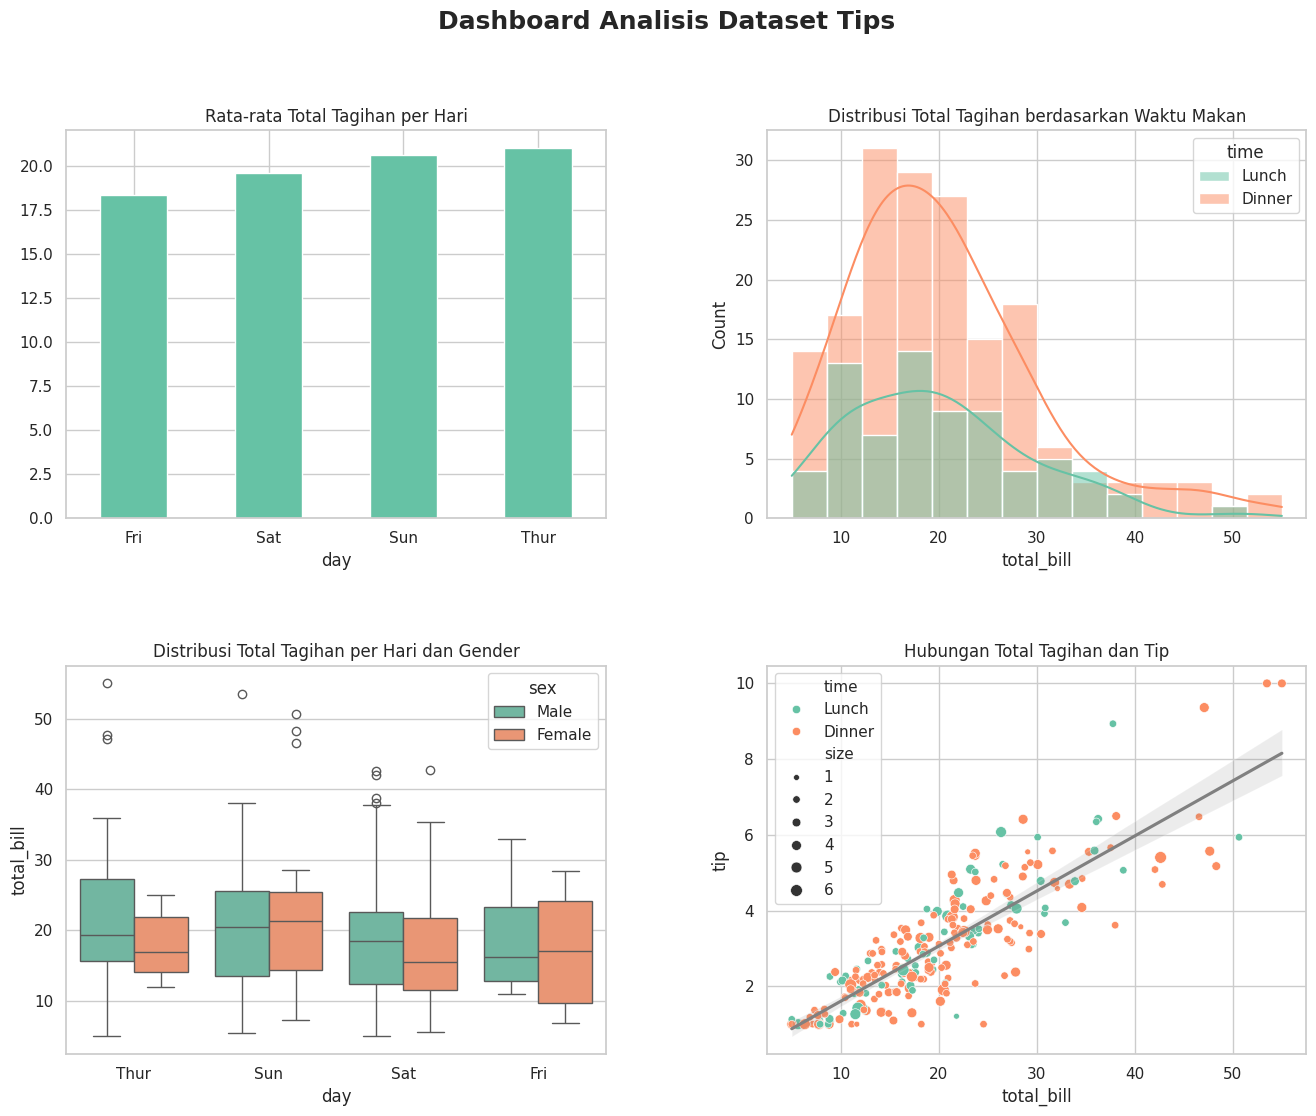

In [2]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Dashboard Analisis Dataset Tips", fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

df.groupby("day", observed=False)["total_bill"].mean().plot(kind="bar", ax=ax1)
ax1.set_title("Rata-rata Total Tagihan per Hari")
ax1.tick_params(axis="x", rotation=0)

sns.histplot(data=df, x="total_bill", hue="time", kde=True, ax=ax2)
ax2.set_title("Distribusi Total Tagihan berdasarkan Waktu Makan")

sns.boxplot(data=df, x="day", y="total_bill", hue="sex", ax=ax3)
ax3.set_title("Distribusi Total Tagihan per Hari dan Gender")

sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", size="size", ax=ax4)
sns.regplot(data=df, x="total_bill", y="tip", scatter=False, color="gray", ax=ax4)
ax4.set_title("Hubungan Total Tagihan dan Tip")

plt.savefig("dashboard_tips_nabil.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Insight What, So What, Now What

**What?** Dashboard menunjukkan pola total tagihan, waktu makan, gender, dan hubungan total tagihan dengan tip.

**So what?** Total tagihan dan tip cenderung memiliki hubungan positif.

**Now what?** Restoran dapat memanfaatkan insight ini untuk strategi pelayanan, stok bahan, dan promosi pada waktu yang ramai.


## Kesimpulan

Saya mempelajari pembuatan dashboard visualisasi statis. Temuan utama adalah tip cenderung meningkat ketika total tagihan meningkat. Keterbatasannya, dataset Tips relatif kecil.
